# Results Dashboard

Benchmark results tables. Full analysis (charts, ablations) in `00a_results_analysis.ipynb`.

In [43]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from notebook_utils import (
    ADMET_TASK_ORDER, TASK_CATEGORY, TASK_METRICS, TDC_SOTA,
    MINIMOL_GIT, MOLE, MOLGPS, FAMILY_HATCHES,
    infer_model_name, infer_model_family, build_method_label,
    load_results, load_tdc_top10, count_best_among_methods, build_method_colors,
)

# === Config: select which model(s) to show ===
MODELS_TO_SHOW = [
    'pairmixer_12M',
    'pairmixer_20M',
]

df, admet_df = load_results(models_to_show=MODELS_TO_SHOW)
print(f"Loaded {len(df)} rows, {len(admet_df)} ADMET rows")
print(f"Models: {sorted(df['model_name'].unique())}")
print(f"Methods: {sorted(admet_df['method'].unique())}")

# Method colors: consistent color per pre-training dataset
METHOD_COLORS = build_method_colors(admet_df)

# TDC top-10 leaderboard stats for z-score normalization
TDC_TOP10_ALL, TDC_TOP10_AVG, TDC_TOP10_MEDIAN = load_tdc_top10()


def _to_clean_latex(_df, *, multirow=True):
    """Render a LaTeX table in the paper's house style: booktabs rules, outer index
    levels collapsed into a gray ``\\rowcolor{gray!12}\\multicolumn{...}{l}{\\textit{...}}``
    category header, the innermost index level as the row label, and metric column
    headers rendered as ``name ($\\uparrow$)`` / ``name ($\\downarrow$)``. Underscores
    and percent signs in headers/index labels are escaped for LaTeX; data values are
    written verbatim so existing ``\\textbf{...}`` markup is preserved.

    Requires ``\\usepackage[table]{xcolor}`` in the document preamble.
    The ``multirow`` kwarg is accepted for API compatibility but unused."""
    del multirow  # accepted for API compatibility

    def _latex_safe(_s, *, escape_underscore=True):
        _s = str(_s)
        if escape_underscore:
            _s = _s.replace('_', r'\_')
        for _u, _t in (
            ('%',  r'\%'),
            ('&',  r'\&'),
            ('#',  r'\#'),
            ('≤',  r'$\leq$'),
            ('≥',  r'$\geq$'),
            ('±',  r'$\pm$'),
            ('×',  r'$\times$'),
            ('→',  r'$\to$'),
        ):
            _s = _s.replace(_u, _t)
        return _s

    def _esc(_s):
        return _latex_safe(_s, escape_underscore=True)

    def _fmt_val(_v):
        if pd.isna(_v):
            return ''
        # Skip underscore escape so any pre-formatted LaTeX markup (e.g. \textbf{})
        # in cell values is preserved untouched.
        return _latex_safe(_v, escape_underscore=False)

    if isinstance(_df.index, pd.MultiIndex) and _df.index.nlevels > 1:
        _outer = [' / '.join(_esc(_x) for _x in _row[:-1]) for _row in _df.index]
        _inner = [_esc(_row[-1]) for _row in _df.index]
        _inner_name = _df.index.names[-1] or ''
    else:
        _outer = [None] * len(_df)
        _vals = (_df.index.get_level_values(0)
                 if isinstance(_df.index, pd.MultiIndex) else _df.index)
        _inner = [_esc(_v) for _v in _vals]
        _inner_name = ((_df.index.names[0] if isinstance(_df.index, pd.MultiIndex)
                        else _df.index.name) or '')

    _hdrs = []
    for _c in _df.columns:
        _s = str(_c)
        if '↑' in _s:
            _hdrs.append(f'{_esc(_s.replace("↑", "").strip())} ($\\uparrow$)')
        elif '↓' in _s:
            _hdrs.append(f'{_esc(_s.replace("↓", "").strip())} ($\\downarrow$)')
        else:
            _hdrs.append(_esc(_s))

    _ncols_total = 1 + len(_hdrs)
    _col_spec = 'l' + 'c' * len(_hdrs)

    _has_categories = any(_o is not None for _o in _outer)
    _out = [f'\\begin{{tabular}}{{{_col_spec}}}', '\\toprule']
    _out.append(' & '.join([_esc(_inner_name)] + _hdrs) + r' \\')
    if not _has_categories:
        _out.append('\\midrule')

    _prev_outer = None
    for _i, (_o, _inn) in enumerate(zip(_outer, _inner)):
        if _o is not None and _o != _prev_outer:
            _out.append('\\hline')
            _out.append(
                f'\\rowcolor{{gray!12}}\\multicolumn{{{_ncols_total}}}{{l}}'
                f'{{\\textit{{{_o}}}}}' + r' \\'
            )
            _prev_outer = _o
        _row_vals = [_fmt_val(_df.iloc[_i, _j]) for _j in range(len(_df.columns))]
        _out.append(' & '.join([_inn] + _row_vals) + r' \\')

    _out.extend(['\\bottomrule', '\\end{tabular}'])
    return '\n'.join(_out)

Loaded 754 rows, 264 ADMET rows
Models: ['pairmixer_12M', 'pairmixer_20M']
Methods: ['Scratch', 'dti_pactivity', 'toymix', 'toymix_bbbc047', 'toymix_dti_esmc_v2', 'toymix_dti_pactivity', 'toymix_lpm24']


/home/shpark/prj-molrepr/graphium/notebooks/notebook_utils.py:385: DtypeWarning: Columns (15,17,18,19,21,22,24,311) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


# Task 1 - ADMET

## TDC ADMET

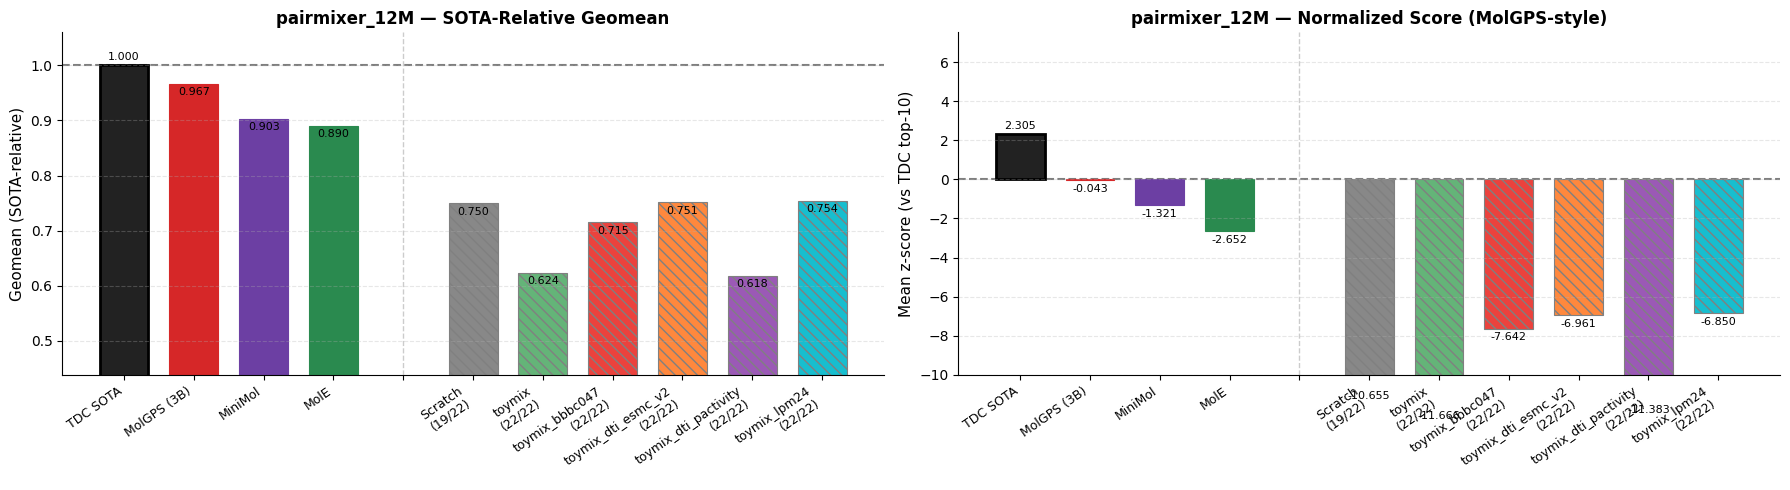


  Method                      Geomean   Z-score  Tasks
  ----------------------------------------------------
  TDC SOTA                     1.0000    2.3046     22
  MolGPS (3B)                  0.9670   -0.0434     22
  MiniMol                      0.9030   -1.3208     22
  MolE                         0.8901   -2.6516     22

  Scratch                      0.7500  -10.6547     19
  toymix                       0.6239  -11.6661     22
  toymix_bbbc047               0.7150   -7.6423     22
  toymix_dti_esmc_v2           0.7514   -6.9608     22
  toymix_dti_pactivity         0.6178  -11.3829     22
  toymix_lpm24                 0.7539   -6.8495     22



/tmp/ipykernel_1100105/215806392.py:167: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


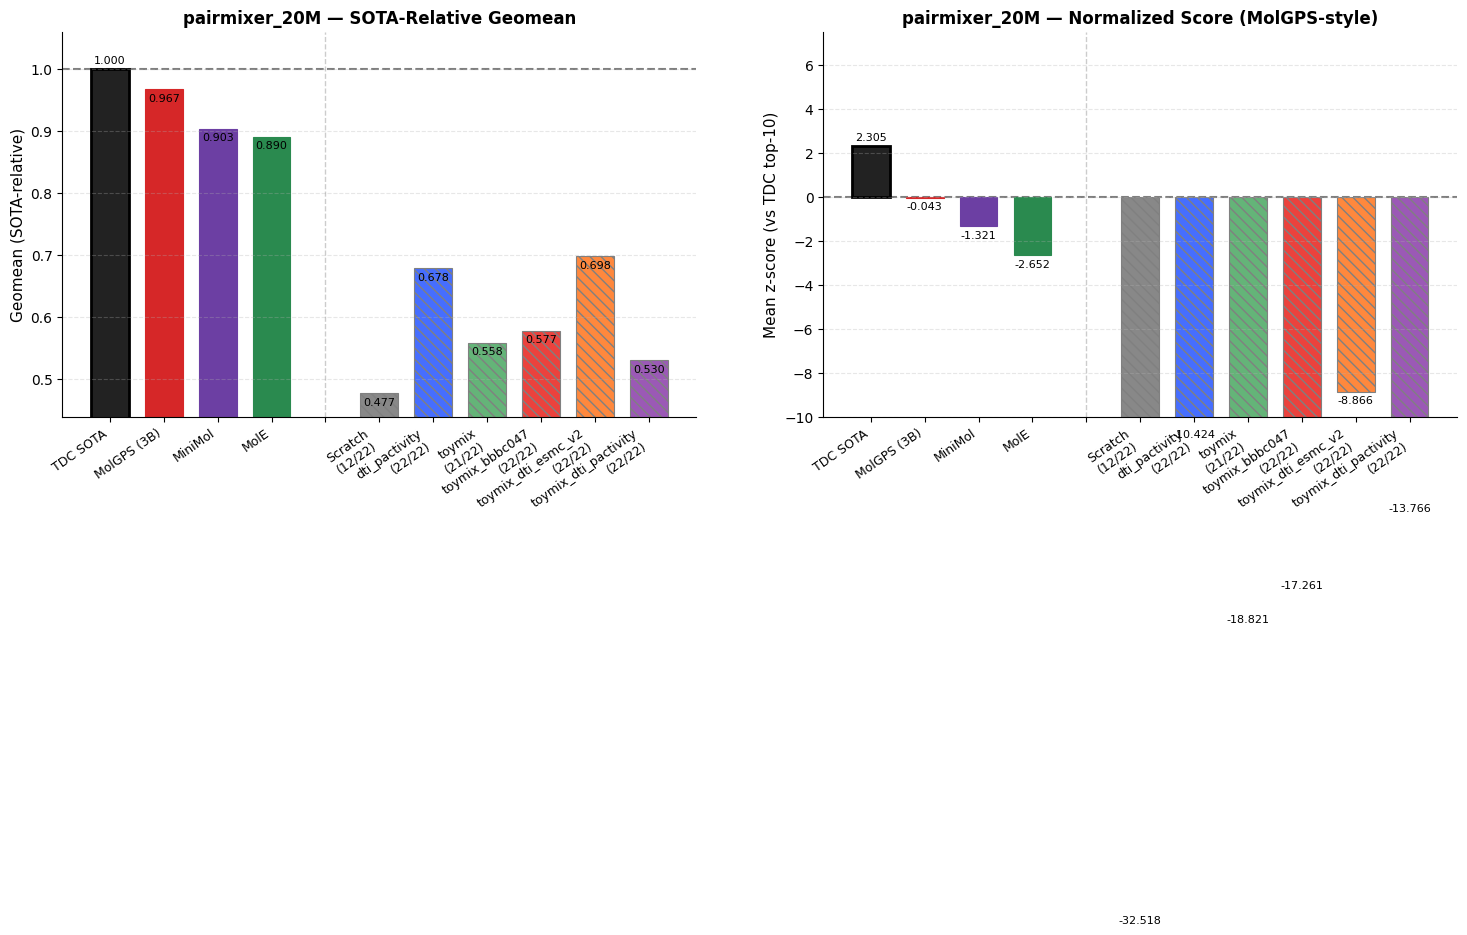


  Method                      Geomean   Z-score  Tasks
  ----------------------------------------------------
  TDC SOTA                     1.0000    2.3046     22
  MolGPS (3B)                  0.9670   -0.0434     22
  MiniMol                      0.9030   -1.3208     22
  MolE                         0.8901   -2.6516     22

  Scratch                      0.4767  -32.5178     12
  dti_pactivity                0.6780  -10.4240     22
  toymix                       0.5580  -18.8214     21
  toymix_bbbc047               0.5774  -17.2606     22
  toymix_dti_esmc_v2           0.6977   -8.8660     22
  toymix_dti_pactivity         0.5295  -13.7664     22



In [44]:
# Two aggregate metrics across 22 ADMET tasks:
#
# 1. SOTA-relative geomean: value/SOTA (higher-better) or SOTA/value (lower-better),
#    then geometric mean. SOTA = 1.0 by construction.
#
# 2. MolGPS-style normalized score: z-score each task relative to the TDC top-10
#    leaderboard, flip sign for lower-is-better, then arithmetic mean.
#    Positive = above leaderboard average, negative = below.

def _sota_normalize(value, task):
    """Normalize a single value relative to TDC SOTA for that task."""
    if task not in TDC_SOTA or pd.isna(value):
        return np.nan
    sota_mean = TDC_SOTA[task][0]
    direction = TASK_METRICS[task][1]
    if sota_mean == 0:
        return np.nan
    if direction == 'higher':
        return value / sota_mean
    else:
        return sota_mean / value if value != 0 else np.nan

def _zscore_normalize(value, task):
    """Z-score relative to TDC top-10 leaderboard, sign-flipped for lower-is-better."""
    if task not in TDC_TOP10_AVG or pd.isna(value):
        return np.nan
    lb_mean, lb_std = TDC_TOP10_AVG[task]
    if lb_std < 1e-12:
        return 0.0
    direction = TASK_METRICS[task][1]
    z = (value - lb_mean) / lb_std
    return z if direction == 'higher' else -z

def _geomean(values):
    """Geometric mean of positive values, ignoring NaN."""
    v = [x for x in values if np.isfinite(x) and x > 0]
    if not v:
        return np.nan
    return np.exp(np.mean(np.log(v)))

def _mean_zscore(values):
    """Arithmetic mean of z-scores, ignoring NaN."""
    v = [x for x in values if np.isfinite(x)]
    if not v:
        return np.nan
    return np.mean(v)

# --- External baselines: (display_label, data_dict, bar_color) ---
_BASELINES = [
    ('TDC SOTA',     {t: (TDC_SOTA[t][0],) for t in ADMET_TASK_ORDER if t in TDC_SOTA}, '#222222'),
    ('MolGPS (3B)',  MOLGPS,       '#d62728'),
    ('MiniMol',      MINIMOL_GIT,  '#6c3fa3'),
    ('MolE',         MOLE,         '#2a8a4f'),
]

_baseline_geomeans = {}
_baseline_zscores = {}
for _bname, _bdata, _ in _BASELINES:
    _gn = [_sota_normalize(_bdata[t][0], t) for t in ADMET_TASK_ORDER if t in _bdata]
    _zn = [_zscore_normalize(_bdata[t][0], t) for t in ADMET_TASK_ORDER if t in _bdata]
    _baseline_geomeans[_bname] = _geomean(_gn)
    _baseline_zscores[_bname] = _mean_zscore(_zn)

# --- Compute per (model, method) from our runs ---
if len(admet_df) > 0 and admet_df['primary_metric'].notna().any():
    _task_method_means = admet_df.groupby(['task', 'model_name', 'method'])['primary_metric'].mean()

    _all_geomeans = list(_baseline_geomeans.values())
    _all_zscores = list(_baseline_zscores.values())
    _model_data = {}

    for model_name in MODELS_TO_SHOW:
        model_df = admet_df[admet_df['model_name'] == model_name]
        if len(model_df) == 0:
            continue
        methods = sorted(model_df['method'].unique(), key=lambda m: (0 if m == 'Scratch' else 1, m))
        _method_geomeans = {}
        _method_zscores = {}
        _method_ntasks = {}
        for method in methods:
            _gn, _zn = [], []
            for task in ADMET_TASK_ORDER:
                try:
                    val = _task_method_means.loc[(task, model_name, method)]
                    _gn.append(_sota_normalize(val, task))
                    _zn.append(_zscore_normalize(val, task))
                except KeyError:
                    pass
            _method_geomeans[method] = _geomean(_gn)
            _method_zscores[method] = _mean_zscore(_zn)
            _method_ntasks[method] = sum(1 for x in _gn if np.isfinite(x) and x > 0)
            if np.isfinite(_method_geomeans[method]):
                _all_geomeans.append(_method_geomeans[method])
            if np.isfinite(_method_zscores[method]):
                _all_zscores.append(_method_zscores[method])
        _model_data[model_name] = (methods, _method_geomeans, _method_zscores, _method_ntasks)

    # Shared y-axis ranges
    _gm_finite = [v for v in _all_geomeans if np.isfinite(v)]
    _gm_ymin = min(_gm_finite) * 0.92 if _gm_finite else 0
    _gm_ymax = max(_gm_finite) * 1.06 if _gm_finite else 1
    _zs_finite = [v for v in _all_zscores if np.isfinite(v)]
    _zs_pad = (max(_zs_finite) - min(_zs_finite)) * 0.15 if _zs_finite else 1
    _zs_ymin = max(min(_zs_finite) - _zs_pad, -10) if _zs_finite else -1
    _zs_ymax = max(_zs_finite) + _zs_pad if _zs_finite else 1

    baseline_names = [name for name, _, _ in _BASELINES]
    baseline_colors = {name: color for name, _, color in _BASELINES}

    for model_name in MODELS_TO_SHOW:
        if model_name not in _model_data:
            continue
        methods, _mg, _mz, _mnt = _model_data[model_name]
        family = infer_model_family(model_name)
        hatch = FAMILY_HATCHES.get(family, '')

        all_labels = baseline_names + [''] + methods
        gm_vals = [_baseline_geomeans[b] for b in baseline_names] + [np.nan] + [_mg[m] for m in methods]
        zs_vals = [_baseline_zscores[b] for b in baseline_names] + [np.nan] + [_mz[m] for m in methods]
        n = len(all_labels)
        x = np.arange(n)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(max(18, n * 1.6), 5))

        for ax, vals, ylabel, title_suffix, ymin, ymax, refline in [
            (ax1, gm_vals, 'Geomean (SOTA-relative)', 'SOTA-Relative Geomean', _gm_ymin, _gm_ymax, 1.0),
            (ax2, zs_vals, 'Mean z-score (vs TDC top-10)', 'Normalized Score (MolGPS-style)', _zs_ymin, _zs_ymax, 0.0),
        ]:
            for i, (label, val) in enumerate(zip(all_labels, vals)):
                if label == '' or pd.isna(val):
                    continue
                if label in baseline_colors:
                    color = baseline_colors[label]
                    h = ''
                    ec = 'black' if label == 'TDC SOTA' else color
                    lw = 2.0 if label == 'TDC SOTA' else 0.8
                else:
                    color = METHOD_COLORS.get(label, '#466eff')
                    h = hatch
                    ec = 'grey' if h else color
                    lw = 0.8
                ax.bar(i, val, color=color, hatch=h, edgecolor=ec, linewidth=lw, width=0.7)
                offset = (ymax - ymin) * 0.01
                va = 'bottom' if val >= refline else 'top'
                ax.text(i, val + (offset if va == 'bottom' else -offset),
                        f'{val:.3f}', ha='center', va=va, fontsize=8)

            ax.axhline(y=refline, color='black', linewidth=1.5, linestyle='--', alpha=0.5, zorder=0)
            sep_x = len(baseline_names)
            ax.axvline(x=sep_x - 0.5 + 0.5, color='grey', linewidth=1, linestyle='--', alpha=0.4)
            ax.set_xticks(x)
            _xlabels = []
            for label in all_labels:
                if label == '' or label in baseline_colors:
                    _xlabels.append(label)
                else:
                    _nt = _mnt.get(label, 0)
                    _xlabels.append(f'{label}\n({_nt}/{len(ADMET_TASK_ORDER)})')
            ax.set_xticklabels(_xlabels, rotation=35, ha='right', fontsize=9)
            ax.set_ylabel(ylabel, fontsize=11)
            ax.set_title(f'{model_name} — {title_suffix}', fontsize=12, fontweight='bold')
            ax.set_ylim(ymin, ymax)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(True, axis='y', ls='--', alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Print table
        print(f"\n{'':2s}{'Method':25s}  {'Geomean':>8s}  {'Z-score':>8s}  {'Tasks':>5s}")
        print("  " + "-" * 52)
        for b in baseline_names:
            print(f"  {b:25s}  {_baseline_geomeans[b]:>8.4f}  {_baseline_zscores[b]:>8.4f}  {22:>5d}")
        print()
        for m in methods:
            print(f"  {m:25s}  {_mg[m]:>8.4f}  {_mz[m]:>8.4f}  {_mnt[m]:>5d}")
        print()
else:
    print("No ADMET results to plot.")

In [45]:
print(f"ADMET results: {len(admet_df)} rows")
print(f"Methods: {sorted(admet_df['method'].unique())}")

# --- Compute global best (across all architectures) per task ---
global_best_per_task = {}  # task -> (model_name, method)
if len(admet_df) > 0 and admet_df['primary_metric'].notna().any():
    for task in ADMET_TASK_ORDER:
        task_rows = admet_df[admet_df['task'] == task].dropna(subset=['primary_metric'])
        if len(task_rows) == 0:
            continue
        direction = TASK_METRICS.get(task, (None, 'higher'))[1]
        if direction == 'lower':
            best_row = task_rows.loc[task_rows['primary_metric'].idxmin()]
        else:
            best_row = task_rows.loc[task_rows['primary_metric'].idxmax()]
        global_best_per_task[task] = (best_row['model_name'], best_row['method'])

# --- Display one table per architecture ---
if len(admet_df) > 0 and admet_df['primary_metric'].notna().any():
    for model_name in MODELS_TO_SHOW:
        model_df = admet_df[admet_df['model_name'] == model_name]

        if len(model_df) == 0 or model_df['primary_metric'].isna().all():
            # No data at all — show empty table with all tasks
            pivot = pd.DataFrame(index=ADMET_TASK_ORDER, columns=['(no results)'])
            pivot['(no results)'] = np.nan
        else:
            pivot = model_df.pivot_table(
                index='task', columns='method', values='primary_metric', aggfunc='mean'
            )
            method_order = ['Scratch'] + sorted([c for c in pivot.columns if c != 'Scratch'])
            method_order += [c for c in pivot.columns if c not in method_order]
            pivot = pivot[[c for c in method_order if c in pivot.columns]]

        # Reindex to always show all 22 ADMET tasks (NaN for missing)
        pivot = pivot.reindex(ADMET_TASK_ORDER)

        row_labels = []
        for task in pivot.index:
            metric_name, direction = TASK_METRICS.get(task, ('?', 'higher'))
            arrow = '\u2191' if direction == 'higher' else '\u2193'
            row_labels.append(f'{task}  ({metric_name} {arrow})')

        # Find best column per row within this architecture
        arch_best_per_row = {}
        for task in pivot.index:
            direction = TASK_METRICS.get(task, (None, 'higher'))[1]
            row_vals = pivot.loc[task].dropna()
            if len(row_vals) > 0:
                best_col = row_vals.idxmin() if direction == 'lower' else row_vals.idxmax()
                arch_best_per_row[task] = best_col

        numeric_pivot = pivot.copy()

        # Insert TDC SOTA column on the left
        sota_col = []
        for task in pivot.index:
            if task in TDC_SOTA:
                mean, std, _ = TDC_SOTA[task]
                sota_col.append(f'{mean:.3f} \u00b1 {std:.3f}')
            else:
                sota_col.append('')
        pivot.insert(0, 'TDC SOTA', sota_col)

        # Compute category boundaries
        category_boundaries = set()
        prev_cat = None
        for i, task in enumerate(pivot.index):
            cat = TASK_CATEGORY.get(task)
            if prev_cat is not None and cat != prev_cat:
                category_boundaries.add(i)
            prev_cat = cat

        display_pivot = pivot.copy()
        display_pivot.index = row_labels

        # Styling: bold = best within arch, blue+underline = best across all archs
        def make_highlight(arch_best, global_best, cur_model, dp, pv):
            def highlight(row):
                task = pv.index[dp.index.get_loc(row.name)]
                styles = [''] * len(row)
                cols = list(dp.columns)
                metric_info = TASK_METRICS.get(task, (None, None))
                direction = metric_info[1]
                sota_info = TDC_SOTA.get(task)

                for j, col in enumerate(cols):
                    if col == 'TDC SOTA':
                        continue
                    try:
                        val = float(row.iloc[j])
                    except (ValueError, TypeError):
                        continue
                    if pd.isna(val):
                        continue

                    # Check if value exceeds SOTA (within std)
                    exceeds_sota = False
                    if sota_info is not None and direction is not None:
                        sota_mean, sota_std, _ = sota_info
                        if direction == 'higher' and val >= sota_mean - sota_std:
                            exceeds_sota = True
                        elif direction == 'lower' and val <= sota_mean + sota_std:
                            exceeds_sota = True

                    if exceeds_sota:
                        styles[j] = 'font-weight: bold; color: #cc0000'

                # Architecture best: bold (overrides red if not exceeding SOTA)
                if task in arch_best:
                    j = cols.index(arch_best[task])
                    if 'color: #cc0000' not in styles[j]:
                        styles[j] = 'font-weight: bold'

                # Global best: blue + underline (overrides arch-best, but not red)
                if task in global_best:
                    g_model, g_method = global_best[task]
                    if g_model == cur_model and g_method in cols:
                        k = cols.index(g_method)
                        if 'color: #cc0000' not in styles[k]:
                            styles[k] = 'font-weight: bold; color: #1a5fb4; text-decoration: underline'

                return styles
            return highlight

        def make_category_borders(boundaries, dp):
            def category_borders(row):
                idx = dp.index.get_loc(row.name)
                if idx in boundaries:
                    return ['border-top: 3px solid black'] * len(row)
                return [''] * len(row)
            return category_borders

        def sota_style(col):
            if col.name == 'TDC SOTA':
                return ['background-color: #f0f0f0; color: #555; font-size: 0.9em'] * len(col)
            return [''] * len(col)

        styled = (
            display_pivot.style
            .format(precision=4, na_rep='',
                    subset=[c for c in display_pivot.columns if c != 'TDC SOTA'])
            .apply(make_highlight(arch_best_per_row, global_best_per_task,
                                  model_name, display_pivot, pivot), axis=1)
            .apply(make_category_borders(category_boundaries, display_pivot), axis=1)
            .apply(sota_style, axis=0)
            .set_caption(f'{model_name} — ADMET Performance (TDC SOTA on left for reference)')
            .set_table_styles([
                {'selector': 'th', 'props': [('font-weight', 'bold')]},
                {'selector': 'td', 'props': [('text-align', 'center')]},
            ])
        )

        print(f"\n{'='*60}")
        print(f"  {model_name}")
        print(f"{'='*60}")
        print("Bold = best within architecture | Blue + underline = best across all architectures")
        display(styled)

        # Count tasks where each method is the best
        best_counts = count_best_among_methods(numeric_pivot, list(numeric_pivot.columns), TASK_METRICS)
        if best_counts:
            print(f"\nTasks where each method is best ({model_name}):")
            for method, (wins, total) in best_counts.items():
                print(f"  {method}: {wins}/{total}")

    # --- Cross-architecture summary ---
    combined_pivot = admet_df.pivot_table(
        index='task', columns=['model_name', 'method'],
        values='primary_metric', aggfunc='mean'
    )
    combined_pivot = combined_pivot.loc[[t for t in ADMET_TASK_ORDER if t in combined_pivot.index]]
    all_cols = list(combined_pivot.columns)
    best_counts = count_best_among_methods(combined_pivot, all_cols, TASK_METRICS)

    print(f"\n{'='*60}")
    print("  Cross-architecture summary: tasks where each (model, method) is best")
    print(f"{'='*60}")
    for col, (wins, total) in best_counts.items():
        model, method = col
        print(f"  {model} / {method}: {wins}/{total}")
else:
    print("No ADMET results found yet. Run experiments first.")

ADMET results: 264 rows
Methods: ['Scratch', 'dti_pactivity', 'toymix', 'toymix_bbbc047', 'toymix_dti_esmc_v2', 'toymix_dti_pactivity', 'toymix_lpm24']

  pairmixer_12M
Bold = best within architecture | Blue + underline = best across all architectures


method,TDC SOTA,Scratch,toymix,toymix_bbbc047,toymix_dti_esmc_v2,toymix_dti_pactivity,toymix_lpm24
caco2_wang (mae ↓),0.256 ± 0.006,0.5742,0.8164,0.5547,0.5234,0.8711,0.5352
hia_hou (auroc ↑),0.993 ± 0.005,0.8298,0.9374,0.9652,0.9492,0.9323,0.9165
pgp_broccatelli (auroc ↑),0.948 ± 0.000,0.8675,0.9020,0.9029,0.8924,0.8932,0.8732
bioavailability_ma (auroc ↑),0.938 ± 0.002,0.6408,0.5883,0.7281,0.6147,0.6018,0.6142
lipophilicity_astrazeneca (mae ↓),0.386 ± 0.000,0.5469,0.9375,0.8828,0.8242,0.9062,0.8398
solubility_aqsoldb (mae ↓),0.679 ± 0.000,0.7812,1.1797,1.0938,1.0156,1.1562,1.0938
bbb_martins (auroc ↑),0.941 ± 0.000,0.8928,0.7690,0.8040,0.8668,0.7849,0.8952
ppbr_az (mae ↓),6.464 ± 0.000,26.5000,11.6875,8.4375,8.5625,10.7500,8.5625
vdss_lombardo (spearman ↑),0.713 ± 0.007,0.6016,0.4766,0.5664,0.5703,0.4395,0.5312
cyp2d6_veith (auprc ↑),0.790 ± 0.001,0.5418,0.4979,0.4946,0.6188,0.4806,0.5830



Tasks where each method is best (pairmixer_12M):
  Scratch: 6/22
  toymix: 0/22
  toymix_bbbc047: 5/22
  toymix_dti_esmc_v2: 5/22
  toymix_dti_pactivity: 0/22
  toymix_lpm24: 6/22

  pairmixer_20M
Bold = best within architecture | Blue + underline = best across all architectures


method,TDC SOTA,Scratch,dti_pactivity,toymix,toymix_bbbc047,toymix_dti_esmc_v2,toymix_dti_pactivity
caco2_wang (mae ↓),0.256 ± 0.006,1.0859,0.4355,0.9844,0.6094,0.4551,0.6484
hia_hou (auroc ↑),0.993 ± 0.005,0.7864,0.8663,0.7852,0.8374,0.9352,0.9471
pgp_broccatelli (auroc ↑),0.948 ± 0.000,0.8507,0.8286,0.8116,0.7696,0.8819,0.8551
bioavailability_ma (auroc ↑),0.938 ± 0.002,0.6811,0.6162,0.6746,0.4995,0.7183,0.6274
lipophilicity_astrazeneca (mae ↓),0.386 ± 0.000,0.8086,0.8672,0.9570,0.9844,0.9141,0.9531
solubility_aqsoldb (mae ↓),0.679 ± 0.000,0.8867,1.2422,1.5938,1.8906,1.3203,1.4297
bbb_martins (auroc ↑),0.941 ± 0.000,0.7347,0.8249,0.4757,0.6435,0.7682,0.7001
ppbr_az (mae ↓),6.464 ± 0.000,74.5000,11.1250,10.5625,9.8750,9.0000,10.7500
vdss_lombardo (spearman ↑),0.713 ± 0.007,0.5234,0.5273,0.2656,0.4336,0.5977,0.5664
cyp2d6_veith (auprc ↑),0.790 ± 0.001,0.1687,0.4576,0.3445,0.2788,0.3914,0.3144



Tasks where each method is best (pairmixer_20M):
  Scratch: 2/22
  dti_pactivity: 6/22
  toymix: 0/22
  toymix_bbbc047: 1/22
  toymix_dti_esmc_v2: 12/22
  toymix_dti_pactivity: 1/22

  Cross-architecture summary: tasks where each (model, method) is best
  pairmixer_12M / Scratch: 6/22
  pairmixer_12M / toymix: 0/22
  pairmixer_12M / toymix_bbbc047: 4/22
  pairmixer_12M / toymix_dti_esmc_v2: 4/22
  pairmixer_12M / toymix_dti_pactivity: 0/22
  pairmixer_12M / toymix_lpm24: 6/22
  pairmixer_20M / Scratch: 0/22
  pairmixer_20M / dti_pactivity: 1/22
  pairmixer_20M / toymix: 0/22
  pairmixer_20M / toymix_bbbc047: 0/22
  pairmixer_20M / toymix_dti_esmc_v2: 1/22
  pairmixer_20M / toymix_dti_pactivity: 0/22


## Polaris ADME-Fang

Six single-task regression benchmarks from the Polaris `biogen/adme-fang-v1` suite.
Primary metric: **Pearson r** (higher is better).

In [46]:
_FANG_TASKS = [
    'adme_fang_hclint', 'adme_fang_rclint', 'adme_fang_perm',
    'adme_fang_hppb', 'adme_fang_rppb', 'adme_fang_solu',
]
_FANG_LABELS = {
    'adme_fang_hclint': 'Human CLint',
    'adme_fang_rclint': 'Rat CLint',
    'adme_fang_perm':   'Permeability',
    'adme_fang_hppb':   'Human PPB',
    'adme_fang_rppb':   'Rat PPB',
    'adme_fang_solu':   'Solubility',
}
_FANG_METRIC_COLS = [
    ('pearsonr',  'pearsonr ↑',  'higher', True),   # main metric
    ('spearmanr', 'spearmanr ↑', 'higher', False),
    ('r2_score',  'r2 ↑',        'higher', False),
    ('mae',       'mae ↓',       'lower',  False),
    ('mse',       'mse ↓',       'lower',  False),
]

# Polaris leaderboard SOTA (pearsonr, rank #1). Source: polarishub.io, 2026-04.
# _FANG_SOTA = {
#     'adme_fang_perm':   ('(unnamed)',  0.725),
#     'adme_fang_hppb':   ('MolGPS-ens', 0.886),
#     'adme_fang_rppb':   ('MolGPS-ens', 0.892),
#     'adme_fang_solu':   ('MolGPS-ens', 0.781),
# }

# --- graphium-train rows (from experiment_results.csv) ---
_fang_df = df[df['task'].isin(_FANG_TASKS)].copy()
_fang_df['method'] = _fang_df.apply(build_method_label, axis=1)
_fang_df['model_name'] = _fang_df.apply(infer_model_name, axis=1)
_fang_df = _fang_df[_fang_df['model_name'] != 'pairmixer_20M']

# Dedup to latest run per (task, model_name, method)
_fang_df['timestamp'] = pd.to_datetime(_fang_df['timestamp'], errors='coerce')
_fang_df = _fang_df.sort_values('timestamp').drop_duplicates(
    subset=['task', 'model_name', 'method'], keep='last'
).reset_index(drop=True)

# --- Frozen-feature baselines (sklearn head on pretrained embeddings) ---
# Each CSV is long-format: one row per (benchmark, task, seed, head). We aggregate
# over seeds and render mean +/- std for multi-seed runs, bare mean for single-seed.
_FROZEN_SOURCES = [
    # (csv_name, model_label_fn, method_label_fn)
    ('pairmixer_admet_results.csv',
     lambda r: (r.get('ckpt_tag') or r.get('model') or 'pairmixer'),
     lambda r: f"frozen-{r.get('head', 'mlp')}"),
    ('minimol_results.csv',
     lambda r: 'MiniMol',
     lambda r: f"frozen-{r.get('head', 'mlp')}"),
    ('mole_results.csv',
     lambda r: 'MolE',
     lambda r: f"frozen-{r.get('head', 'mlp')}"),
]
_frozen_metric_names = [m[0] for m in _FANG_METRIC_COLS]
_frozen_rows_by_task = {t: [] for t in _FANG_TASKS}
for _csv_name, _model_fn, _method_fn in _FROZEN_SOURCES:
    _p = Path(f'../results/{_csv_name}')
    if not _p.exists():
        continue
    _ext = pd.read_csv(_p)
    if 'benchmark' in _ext.columns:
        _ext = _ext[_ext['benchmark'] == 'polaris']
    _ext = _ext[_ext['task'].isin(_FANG_TASKS)].copy()
    if len(_ext) == 0:
        continue
    _ext['_model'] = _ext.apply(_model_fn, axis=1)
    _ext['_method'] = _ext.apply(_method_fn, axis=1)
    _agg_cols = [c for c in _frozen_metric_names if c in _ext.columns]
    if not _agg_cols:
        continue
    _grp = _ext.groupby(['task', '_model', '_method'])[_agg_cols].agg(['mean', 'std', 'count'])
    for (_task_key, _model_label, _method_label), _r in _grp.iterrows():
        _frozen_rows_by_task[_task_key].append({
            'model_label': _model_label,
            'method_label': _method_label,
            'stats': {m: (_r[(m, 'mean')], _r[(m, 'std')], int(_r[(m, 'count')])) for m in _agg_cols},
        })

if len(_fang_df) > 0 or any(_frozen_rows_by_task.values()):
    _rows = []
    for _task in _FANG_TASKS:
        _label = _FANG_LABELS[_task]
        _tdf = _fang_df[_fang_df['task'] == _task]
        _frozen_here = _frozen_rows_by_task.get(_task, [])

        # SOTA row
        # if _task in _FANG_SOTA:
        #     _sname, _sval = _FANG_SOTA[_task]
        #     _sr = {'Task': _label, 'Model': _sname + ' (SOTA)'}
        #     for _msuf, _mdisp, _, _is_main in _FANG_METRIC_COLS:
        #         _sr[_mdisp] = f'{_sval:.3f}' if _msuf == 'pearsonr' else ''
        #     _rows.append(_sr)

        if len(_tdf) == 0 and not _frozen_here:
            _row = {'Task': _label, 'Model': '(no results)'}
            for _, _mdisp, _, _ in _FANG_METRIC_COLS:
                _row[_mdisp] = '-'
            _rows.append(_row)
            continue

        # graphium-train rows
        for _, _r in _tdf.iterrows():
            _mname = _r['model_name']
            _method = _r['method']
            _row = {'Task': _label, 'Model': f'{_mname} / {_method}'}
            for _msuf, _mdisp, _, _ in _FANG_METRIC_COLS:
                _col = [c for c in _tdf.columns
                        if _task in c and f'/{_msuf}/' in c and 'test' in c]
                _val = pd.to_numeric(_r[_col[0]], errors='coerce') if _col else np.nan
                _row[_mdisp] = f'{_val:.4f}' if pd.notna(_val) else '-'
            _rows.append(_row)

        # frozen-feature rows (mean +/- std over seeds)
        for _fr in _frozen_here:
            _row = {
                'Task': _label,
                'Model': f"{_fr['model_label']} / {_fr['method_label']}",
            }
            for _msuf, _mdisp, _, _ in _FANG_METRIC_COLS:
                _st = _fr['stats'].get(_msuf)
                if _st is None or pd.isna(_st[0]):
                    _row[_mdisp] = '-'
                else:
                    _mean, _std, _n = _st
                    if _n > 1 and pd.notna(_std):
                        _row[_mdisp] = f'{_mean:.4f} ± {_std:.4f}'
                    else:
                        _row[_mdisp] = f'{_mean:.4f}'
            _rows.append(_row)

    _result = pd.DataFrame(_rows)
    _metric_cols = [d for _, d, _, _ in _FANG_METRIC_COLS]
    _main_col = [d for _, d, _, m in _FANG_METRIC_COLS if m][0]
    _metric_dir = {_d: _dir for _, _d, _dir, _ in _FANG_METRIC_COLS}

    # Multi-row index: group by Task
    _result = _result.set_index(['Task', 'Model'])

    def _parse_mean(_v):
        if not isinstance(_v, str) or _v in ('', '-'):
            return np.nan
        try:
            return float(_v.split('±')[0].strip())
        except ValueError:
            return np.nan

    def _style_fang(_s):
        _styles = pd.DataFrame('', index=_s.index, columns=_s.columns)
        # Bold best score per task per metric (excluding SOTA rows)
        for _task_label in _s.index.get_level_values(0).unique():
            _task_block = _s.loc[_task_label]
            _model_idx = _task_block.index.astype(str)
            _non_sota_models = [_m for _m in _model_idx if '(SOTA)' not in _m]
            if not _non_sota_models:
                continue
            _block = _task_block.loc[_non_sota_models]
            for _col in _s.columns:
                _vals = _block[_col].map(_parse_mean)
                if not _vals.notna().any():
                    continue
                _dir = _metric_dir.get(_col, 'higher')
                _best_model = _vals.idxmin() if _dir == 'lower' else _vals.idxmax()
                _styles.loc[(_task_label, _best_model), _col] = 'font-weight: bold'
        # SOTA rows: grey background; main metric bold+underlined ONLY when SOTA beats every model
        for _idx in _s.index:
            if '(SOTA)' not in str(_idx[1]):
                continue
            _styles.loc[_idx] = 'background-color: #f0f0f0; color: #555; font-size: 0.9em'
            if _main_col not in _styles.columns:
                continue
            _sota_val = _parse_mean(_s.loc[_idx, _main_col])
            if pd.isna(_sota_val):
                continue
            _task_label = _idx[0]
            _task_block = _s.loc[_task_label]
            _other_models = [_m for _m in _task_block.index.astype(str) if '(SOTA)' not in _m]
            _other_vals = (_task_block.loc[_other_models, _main_col].map(_parse_mean).dropna()
                           if _other_models else pd.Series(dtype=float))
            _dir = _metric_dir.get(_main_col, 'higher')
            if len(_other_vals) == 0:
                _sota_wins = True
            elif _dir == 'higher':
                _sota_wins = _sota_val >= _other_vals.max()
            else:
                _sota_wins = _sota_val <= _other_vals.min()
            if _sota_wins:
                _styles.loc[_idx, _main_col] = (
                    'background-color: #f0f0f0; font-weight: bold; text-decoration: underline'
                )
        return _styles

    # Compute row-level border positions for task boundaries (full-row via set_table_styles)
    _row_styles = [
        {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center')]},
        {'selector': 'th.row_heading', 'props': [('text-align', 'left')]},
    ]
    _prev_task = None
    for _i, _idx in enumerate(_result.index):
        _cur_task = _idx[0]
        if _prev_task is not None and _cur_task != _prev_task:
            _row_styles.append({
                'selector': f'tbody tr:nth-child({_i + 1})',
                'props': 'border-top: 2px solid #999',
            })
        _prev_task = _cur_task

    _styled = (
        _result.style
        .apply(_style_fang, axis=None)
        .set_caption('ADME Fang (Polaris) — All Metrics (main: pearsonr, underlined)')
        .set_table_styles(_row_styles)
    )
    display(_styled)

    # LaTeX output
    print('\n% LaTeX (copy-paste for paper):')
    print(_to_clean_latex(_result))
else:
    print('No ADME Fang results yet.')



% LaTeX (copy-paste for paper):
\begin{tabular}{lccccc}
\toprule
Model & pearsonr ($\uparrow$) & spearmanr ($\uparrow$) & r2 ($\uparrow$) & mae ($\downarrow$) & mse ($\downarrow$) \\
\hline
\rowcolor{gray!12}\multicolumn{6}{l}{\textit{Human CLint}} \\
pairmixer\_12M / Scratch & 0.5820 & 0.6016 & 0.2617 & 0.3984 & 0.2871 \\
pairmixer\_12M / toymix & 0.5078 & 0.5312 & -0.0312 & 0.4766 & 0.4004 \\
pairmixer\_12M / toymix\_dti\_esmc\_v2 & 0.4707 & 0.4805 & -0.0156 & 0.4727 & 0.3965 \\
pairmixer\_12M\_toymix\_dti\_esmc\_v2 / frozen-mlp & 0.4832 $\pm$ 0.0608 & 0.5075 $\pm$ 0.0527 & 0.0923 $\pm$ 0.1219 & 0.4672 $\pm$ 0.0251 & 0.3527 $\pm$ 0.0474 \\
MiniMol / frozen-mlp & 0.7132 $\pm$ 0.0065 & 0.7039 $\pm$ 0.0062 & 0.4903 $\pm$ 0.0218 & 0.3502 $\pm$ 0.0071 & 0.1980 $\pm$ 0.0085 \\
MolE / frozen-mlp & 0.3718 $\pm$ 0.0700 & 0.3961 $\pm$ 0.0703 & -0.3701 $\pm$ 0.3063 & 0.5610 $\pm$ 0.0615 & 0.5323 $\pm$ 0.1190 \\
\hline
\rowcolor{gray!12}\multicolumn{6}{l}{\textit{Rat CLint}} \\
pairmixer\_12M /

# Task 2 - Protein Related

## DTIAM

GRAM-DTI classification benchmark over 4 DTIAM datasets with 3 split strategies.
Binary classification (drug-target interaction / mechanism-of-action).
Primary metrics: **AUROC** and **AUPRC** (higher is better).

| Subset | Type | Folds | Splits |
|--------|------|-------|--------|
| Yamanishi 08 | DTI | 10 | warm, drug_cold, target_cold |
| Hetionet | DTI | 10 | warm, drug_cold, target_cold |
| Activation | MoA | 5 | warm, drug_cold, target_cold |
| Inhibition | MoA | 5 | warm, drug_cold, target_cold |

In [47]:
_DTIAM_SUBSETS = ['yamanishi_08', 'hetionet', 'activation', 'inhibition']
_DTIAM_METHODS = ['warm', 'drug_cold', 'target_cold']
_DTIAM_METRIC_COLS = [
    ('test_auprc', 'AUPRC \u2191',       'higher', True),   # primary (1:10 imbalance)
    ('test_auroc', 'AUROC \u2191',       'higher', False),
    ('test_f1',    'F1 \u2191',          'higher', False),
    ('test_sensitivity', 'Sens. \u2191', 'higher', False),
    ('test_accuracy',    'Acc. \u2191',  'higher', False),
]
_DTIAM_ENCODER_LABELS = {
    'minimol':   'MiniMol',
    'mole':      'MolE',
    'pairmixer': 'PairMixer 12M',
}

_dtiam_path = Path('../results/downstream/gram_dti.csv')
if _dtiam_path.exists():
    _dtiam_all = pd.read_csv(_dtiam_path)
    _dtiam_all['model_label'] = _dtiam_all['encoder'].map(
        lambda e: _DTIAM_ENCODER_LABELS.get(str(e), str(e))
    )

    _metric_names = [m for m, _, _, _ in _DTIAM_METRIC_COLS if m in _dtiam_all.columns]
    _group_cols = ['model_label', 'subset', 'method']
    _agg = _dtiam_all.groupby(_group_cols)[_metric_names].agg(['mean', 'std', 'count'])

    _models_sorted = sorted({lbl for lbl in _dtiam_all['model_label'].unique()
                             if isinstance(lbl, str) and lbl})

    _rows = []
    for _subset in _DTIAM_SUBSETS:
        for _method in _DTIAM_METHODS:
            for _model_label in _models_sorted:
                _row = {'Subset': _subset, 'Split': _method, 'Model': _model_label}
                try:
                    _stats = _agg.loc[(_model_label, _subset, _method)]
                except KeyError:
                    for _, _disp, _, _ in _DTIAM_METRIC_COLS:
                        _row[_disp] = '-'
                    _rows.append(_row)
                    continue
                for _mn, _disp, _, _ in _DTIAM_METRIC_COLS:
                    if _mn not in _metric_names:
                        _row[_disp] = '-'
                        continue
                    _mean = _stats[(_mn, 'mean')]
                    _std = _stats[(_mn, 'std')]
                    _n = _stats[(_mn, 'count')]
                    if pd.notna(_mean):
                        if pd.notna(_std) and _n > 1:
                            _row[_disp] = f'{_mean:.4f} \u00b1 {_std:.4f}'
                        else:
                            _row[_disp] = f'{_mean:.4f}'
                    else:
                        _row[_disp] = '-'
                _rows.append(_row)

    _result = pd.DataFrame(_rows).set_index(['Subset', 'Split', 'Model'])

    # Bold best model per (subset, split) for each metric.
    def _style_dtiam(_s):
        _styles = pd.DataFrame('', index=_s.index, columns=_s.columns)
        for _subset in _s.index.get_level_values(0).unique():
            for _method in _s.index.get_level_values(1).unique():
                try:
                    _grp = _s.loc[(_subset, _method)]
                except KeyError:
                    continue
                for _mn, _disp, _direction, _is_main in _DTIAM_METRIC_COLS:
                    if _disp not in _s.columns:
                        continue
                    if _mn not in ('test_auprc', 'test_auroc'):
                        continue
                    _vals = []
                    for _model_idx in _grp.index:
                        _raw = str(_grp.loc[_model_idx, _disp]).split(' ')[0]
                        try:
                            _vals.append((_model_idx, float(_raw)))
                        except ValueError:
                            pass
                    if len(_vals) < 2:
                        continue
                    _best = max(_vals, key=lambda x: x[1])[0]
                    _styles.loc[(_subset, _method, _best), _disp] += 'font-weight: bold'
        return _styles

    _row_styles = [
        {'selector': 'td', 'props': [('text-align', 'center')]},
        {'selector': 'th.row_heading', 'props': [('text-align', 'left')]},
    ]
    _prev_subset = None
    _prev_split = None
    for _i, _idx in enumerate(_result.index):
        _cur_subset, _cur_split = _idx[0], _idx[1]
        _nth = _i + 1
        if _prev_subset is not None and _cur_subset != _prev_subset:
            _row_styles.append({
                'selector': f'tbody tr:nth-child({_nth})',
                'props': 'border-top: 3px solid black',
            })
        elif _prev_split is not None and _cur_split != _prev_split:
            _row_styles.append({
                'selector': f'tbody tr:nth-child({_nth})',
                'props': 'border-top: 2px solid #999',
            })
        _prev_subset = _cur_subset
        _prev_split = _cur_split

    _styled = (
        _result.style
        .apply(_style_dtiam, axis=None)
        .set_caption('GRAM-DTI Benchmark \u2014 mean \u00b1 std over CV folds  (primary: AUPRC, bolded)')
        .set_table_styles(_row_styles)
    )
    display(_styled)

    # Bolded LaTeX: wrap best AUPRC/AUROC per (subset, split) in \textbf{}
    _latex_df = _result.copy()
    for _subset in _DTIAM_SUBSETS:
        for _method in _DTIAM_METHODS:
            try:
                _grp = _latex_df.loc[(_subset, _method)]
            except KeyError:
                continue
            for _mn, _disp, _, _ in _DTIAM_METRIC_COLS:
                if _mn not in ('test_auprc', 'test_auroc') or _disp not in _latex_df.columns:
                    continue
                _vals = []
                for _model_idx in _grp.index:
                    _raw = str(_grp.loc[_model_idx, _disp]).split(' ')[0]
                    try:
                        _vals.append((_model_idx, float(_raw)))
                    except ValueError:
                        pass
                if len(_vals) < 2:
                    continue
                _best_model = max(_vals, key=lambda x: x[1])[0]
                _cur = _latex_df.loc[(_subset, _method, _best_model), _disp]
                _latex_df.loc[(_subset, _method, _best_model), _disp] = f'\\textbf{{{_cur}}}'
    print('\n% LaTeX (copy-paste for paper):')
    print(_to_clean_latex(_latex_df))
else:
    print(f'No GRAM-DTI results at {_dtiam_path}. '
          'Run: bash scripts/gram_dti/run_all.sh [pairmixer_ckpt]')

/tmp/ipykernel_1100105/2243989636.py:66: PerformanceWarning: indexing past lexsort depth may impact performance.
  _grp = _s.loc[(_subset, _method)]
/tmp/ipykernel_1100105/2243989636.py:84: PerformanceWarning: indexing past lexsort depth may impact performance.
  _styles.loc[(_subset, _method, _best), _disp] += 'font-weight: bold'



% LaTeX (copy-paste for paper):
\begin{tabular}{lccccc}
\toprule
Model & AUPRC ($\uparrow$) & AUROC ($\uparrow$) & F1 ($\uparrow$) & Sens. ($\uparrow$) & Acc. ($\uparrow$) \\
\hline
\rowcolor{gray!12}\multicolumn{6}{l}{\textit{yamanishi\_08 / warm}} \\
MiniMol & \textbf{0.9120 $\pm$ 0.0091} & \textbf{0.9802 $\pm$ 0.0035} & 0.8534 $\pm$ 0.0090 & 0.8350 $\pm$ 0.0178 & 0.9739 $\pm$ 0.0017 \\
MolE & 0.8903 $\pm$ 0.0135 & 0.9731 $\pm$ 0.0056 & 0.8331 $\pm$ 0.0141 & 0.8104 $\pm$ 0.0247 & 0.9705 $\pm$ 0.0031 \\
PairMixer 12M & 0.8852 $\pm$ 0.0393 & 0.9729 $\pm$ 0.0080 & 0.8299 $\pm$ 0.0399 & 0.8029 $\pm$ 0.0355 & 0.9701 $\pm$ 0.0072 \\
\hline
\rowcolor{gray!12}\multicolumn{6}{l}{\textit{yamanishi\_08 / drug\_cold}} \\
MiniMol & \textbf{0.5573 $\pm$ 0.0553} & \textbf{0.8596 $\pm$ 0.0210} & 0.4824 $\pm$ 0.0760 & 0.3601 $\pm$ 0.0739 & 0.9309 $\pm$ 0.0149 \\
MolE & 0.5075 $\pm$ 0.0567 & 0.8271 $\pm$ 0.0379 & 0.4399 $\pm$ 0.0595 & 0.3179 $\pm$ 0.0582 & 0.9274 $\pm$ 0.0154 \\
PairMixer 12M & 0.484

/tmp/ipykernel_1100105/2243989636.py:122: PerformanceWarning: indexing past lexsort depth may impact performance.
  _grp = _latex_df.loc[(_subset, _method)]
/tmp/ipykernel_1100105/2243989636.py:139: PerformanceWarning: indexing past lexsort depth may impact performance.
  _latex_df.loc[(_subset, _method, _best_model), _disp] = f'\\textbf{{{_cur}}}'


# Task 3 - Cell Related

## Cell Bioactivity

In [48]:
import sys
from pathlib import Path as _Path
_REPO_ROOT = str(_Path('..').resolve())
if _REPO_ROOT not in sys.path:
    sys.path.insert(0, _REPO_ROOT)

from downstream.tasks.bioactivity.report import (
    build_auroc_threshold_table,
    build_macro_summary_table,
)

_BIO_PATH = Path('../results/downstream/bioactivity.csv')


def _style_multiindex_best(_s, *, metric_directions):
    _styles = pd.DataFrame('', index=_s.index, columns=_s.columns)
    for _dataset in _s.index.get_level_values(0).unique():
        for _split in _s.index.get_level_values(1).unique():
            try:
                _grp = _s.loc[(_dataset, _split)]
            except KeyError:
                continue
            for _disp in _s.columns:
                _direction = metric_directions.get(_disp, 'higher')
                _vals = []
                for _model_idx in _grp.index:
                    _raw = str(_grp.loc[_model_idx, _disp]).split(' ')[0]
                    try:
                        _vals.append((_model_idx, float(_raw)))
                    except ValueError:
                        pass
                if len(_vals) < 2:
                    continue
                _best = (
                    max(_vals, key=lambda x: x[1])[0]
                    if _direction == 'higher'
                    else min(_vals, key=lambda x: x[1])[0]
                )
                _styles.loc[(_dataset, _split, _best), _disp] += 'font-weight: bold'
    return _styles


def _multiindex_row_styles(_result):
    _row_styles = [
        {'selector': 'td', 'props': [('text-align', 'center')]},
        {'selector': 'th.row_heading', 'props': [('text-align', 'left')]},
    ]
    _prev_dataset = None
    _prev_split = None
    for _i, _idx in enumerate(_result.index):
        _cur_dataset, _cur_split = _idx[0], _idx[1]
        _nth = _i + 1
        if _prev_dataset is not None and _cur_dataset != _prev_dataset:
            _row_styles.append({
                'selector': f'tbody tr:nth-child({_nth})',
                'props': 'border-top: 3px solid black',
            })
        elif _prev_split is not None and _cur_split != _prev_split:
            _row_styles.append({
                'selector': f'tbody tr:nth-child({_nth})',
                'props': 'border-top: 2px solid #999',
            })
        _prev_dataset = _cur_dataset
        _prev_split = _cur_split
    return _row_styles


def _print_bold_latex(_result, *, metric_directions):
    _latex_df = _result.copy().astype(object)
    for _dataset in _latex_df.index.get_level_values(0).unique():
        for _split in _latex_df.index.get_level_values(1).unique():
            try:
                _grp = _latex_df.loc[(_dataset, _split)]
            except KeyError:
                continue
            for _disp in _latex_df.columns:
                _direction = metric_directions.get(_disp, 'higher')
                _vals = []
                for _model_idx in _grp.index:
                    _raw = str(_grp.loc[_model_idx, _disp]).split(' ')[0]
                    try:
                        _vals.append((_model_idx, float(_raw)))
                    except ValueError:
                        pass
                if len(_vals) < 2:
                    continue
                _best_model = (
                    max(_vals, key=lambda x: x[1])[0]
                    if _direction == 'higher'
                    else min(_vals, key=lambda x: x[1])[0]
                )
                _cur = _latex_df.loc[(_dataset, _split, _best_model), _disp]
                _latex_df.loc[(_dataset, _split, _best_model), _disp] = f'\\textbf{{{_cur}}}'
    print('\n% LaTeX (copy-paste for paper):')
    print(_to_clean_latex(_latex_df))


if _BIO_PATH.exists():
    _bio = pd.read_csv(_BIO_PATH)

    _macro = build_macro_summary_table(_bio).set_index(['Dataset', 'Split', 'Model'])
    _threshold_df = build_auroc_threshold_table(_bio)
    if _threshold_df.empty:
        print('No assay-level AUROC columns found in results/downstream/bioactivity.csv.')
        print('Re-run the bioactivity eval with the updated code to populate test_auroc__assay_* columns.')
        _combined = _macro
    else:
        _threshold_result = _threshold_df.set_index(['Dataset', 'Split', 'Model'])
        _combined = _macro.join(_threshold_result, how='left')

    _metric_directions = {c: 'higher' for c in _combined.columns}
    display(
        _combined.style
        .apply(
            _style_multiindex_best,
            axis=None,
            metric_directions=_metric_directions,
        )
        .set_caption('Cell Bioactivity (Fredinh et al., 2024) — macro AUROC/AUPRC and assays clearing AUROC thresholds (mean ± std across CV folds)')
        .set_table_styles(_multiindex_row_styles(_combined))
    )
    _print_bold_latex(_combined, metric_directions=_metric_directions)
else:
    print(f'No bioactivity results at {_BIO_PATH}. Run: bash scripts/bioactivity/run_all.sh [pairmixer_ckpt]')



% LaTeX (copy-paste for paper):
\begin{tabular}{lccccc}
\toprule
Model & AUROC ($\uparrow$) & AUPRC ($\uparrow$) & AUROC $\geq$ 0.7 & AUROC $\geq$ 0.8 & AUROC $\geq$ 0.9 \\
\hline
\rowcolor{gray!12}\multicolumn{6}{l}{\textit{ChEMBL/JUMP-CP (29 assays) / cv6}} \\
ECFP4 (paper) & 0.7566 $\pm$ 0.0222 & 0.7286 $\pm$ 0.0147 & 20 / 29 (69.0\%) & 11 / 29 (37.9\%) & 0 / 29 (0.0\%) \\
CPCNN (paper cell-painting) & 0.6754 $\pm$ 0.0241 & 0.6820 $\pm$ 0.0228 & 13 / 29 (44.8\%) & 4 / 29 (13.8\%) & 0 / 29 (0.0\%) \\
MiniMol & \textbf{0.8538 $\pm$ 0.0114} & \textbf{0.8206 $\pm$ 0.0167} & \textbf{27 / 29 (93.1\%)} & \textbf{20 / 29 (69.0\%)} & \textbf{15 / 29 (51.7\%)} \\
MolE & 0.7651 $\pm$ 0.0080 & 0.7434 $\pm$ 0.0125 & 21 / 29 (72.4\%) & 12 / 29 (41.4\%) & 2 / 29 (6.9\%) \\
PairMixer 12M & 0.7786 $\pm$ 0.0163 & 0.7499 $\pm$ 0.0197 & 22 / 29 (75.9\%) & 14 / 29 (48.3\%) & 0 / 29 (0.0\%) \\
\bottomrule
\end{tabular}


,EF@1%,EF@5%,EF@10%,Assay wins,Avg rank
Model,,,,,
ECFP4 (paper),2.65 ± 1.93,2.15 ± 1.27,1.95 ± 0.94,0,3.38
CPCNN (paper cell-painting),2.64 ± 2.72,2.08 ± 1.38,1.85 ± 0.97,0,4.52
MiniMol,3.00 ± 2.68,2.66 ± 1.84,2.36 ± 1.37,28,1.07
MolE,2.64 ± 1.90,2.27 ± 1.33,2.02 ± 1.02,0,3.34
PairMixer 12M,2.75 ± 2.14,2.27 ± 1.32,2.05 ± 1.04,1,2.69



% LaTeX (copy-paste for paper):
\begin{tabular}{lccccc}
\toprule
Model & EF@1\% & EF@5\% & EF@10\% & Assay wins & Avg rank \\
\midrule
ECFP4 (paper) & 2.65 $\pm$ 1.93 & 2.15 $\pm$ 1.27 & 1.95 $\pm$ 0.94 & 0 & 3.38 \\
CPCNN (paper cell-painting) & 2.64 $\pm$ 2.72 & 2.08 $\pm$ 1.38 & 1.85 $\pm$ 0.97 & 0 & 4.52 \\
MiniMol & \textbf{3.00 $\pm$ 2.68} & \textbf{2.66 $\pm$ 1.84} & \textbf{2.36 $\pm$ 1.37} & \textbf{28} & \textbf{1.07} \\
MolE & 2.64 $\pm$ 1.90 & 2.27 $\pm$ 1.33 & 2.02 $\pm$ 1.02 & 0 & 3.34 \\
PairMixer 12M & 2.75 $\pm$ 2.14 & 2.27 $\pm$ 1.32 & 2.05 $\pm$ 1.04 & 1 & 2.69 \\
\bottomrule
\end{tabular}


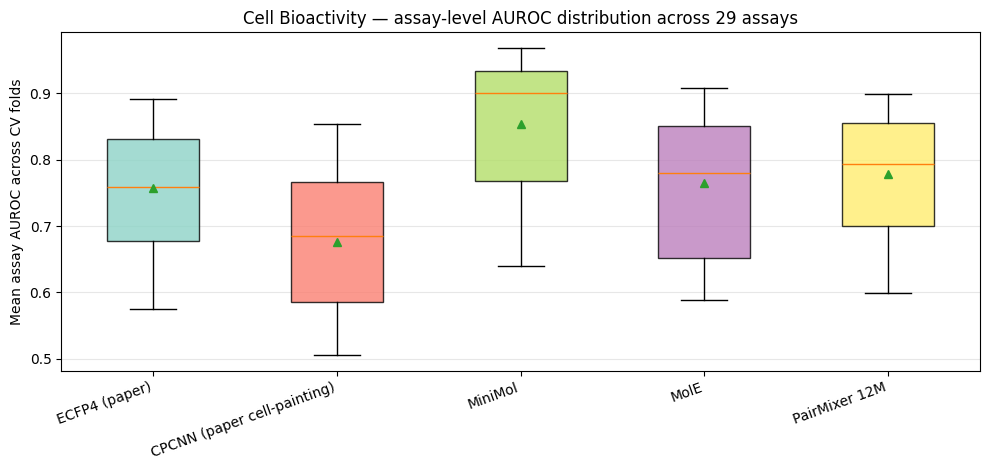

In [49]:
import sys
from pathlib import Path as _Path
_REPO_ROOT = str(_Path('..').resolve())
if _REPO_ROOT not in sys.path:
    sys.path.insert(0, _REPO_ROOT)

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from downstream.tasks.bioactivity.report import (
    DEFAULT_MODEL_ORDER,
    build_assay_auroc_boxplot_frame,
    build_enrichment_factor_table,
    build_per_assay_win_rank_table,
)

_bio_path = Path('../results/downstream/bioactivity.csv')
if not _bio_path.exists():
    print(f'No bioactivity results at {_bio_path}. Run: bash scripts/bioactivity/run_all.sh [pairmixer_ckpt]')
else:
    _bio = pd.read_csv(_bio_path)

    _ef_df = build_enrichment_factor_table(_bio)
    _win_rank_df = build_per_assay_win_rank_table(_bio)

    if _ef_df.empty and _win_rank_df.empty:
        print('No per-assay metrics found in results/downstream/bioactivity.csv.')
        print('Re-run the bioactivity eval with the updated code to populate EF@k% / AUROC metrics.')
    else:
        _key_cols = ['Dataset', 'Split', 'Model']
        if _ef_df.empty:
            _combined = _win_rank_df.copy()
        elif _win_rank_df.empty:
            _combined = _ef_df.copy()
        else:
            _combined = _ef_df.merge(_win_rank_df, on=_key_cols, how='outer')

        # Drop Dataset/Split — only Model remains as the row index for display.
        _result = _combined.drop(columns=['Dataset', 'Split']).set_index('Model')
        _directions = {'Assay wins': 'higher', 'Avg rank': 'lower'}

        def _style_combined(_s):
            _styles = pd.DataFrame('', index=_s.index, columns=_s.columns)
            for _disp in _s.columns:
                _vals = []
                for _model_idx in _s.index:
                    _raw = str(_s.loc[_model_idx, _disp]).split(' ')[0]
                    try:
                        _vals.append((_model_idx, float(_raw)))
                    except ValueError:
                        pass
                if len(_vals) < 2:
                    continue
                _best = (
                    min(_vals, key=lambda x: x[1])[0]
                    if _directions.get(_disp, 'higher') == 'lower'
                    else max(_vals, key=lambda x: x[1])[0]
                )
                _styles.loc[_best, _disp] += 'font-weight: bold'
            return _styles

        _row_styles = [
            {'selector': 'td', 'props': [('text-align', 'center')]},
            {'selector': 'th.row_heading', 'props': [('text-align', 'left')]},
        ]

        display(
            _result.style
            .apply(_style_combined, axis=None)
            .set_caption('Cell Bioactivity — enrichment factor, per-assay AUROC wins, and average rank (higher EF/wins, lower rank are better)')
            .set_table_styles(_row_styles)
        )

        _latex_df = _result.copy().astype(object)
        for _disp in _latex_df.columns:
            _vals = []
            for _model_idx in _latex_df.index:
                _raw = str(_latex_df.loc[_model_idx, _disp]).split(' ')[0]
                try:
                    _vals.append((_model_idx, float(_raw)))
                except ValueError:
                    pass
            if len(_vals) < 2:
                continue
            _best_model = (
                min(_vals, key=lambda x: x[1])[0]
                if _directions.get(_disp, 'higher') == 'lower'
                else max(_vals, key=lambda x: x[1])[0]
            )
            _cur = _latex_df.loc[_best_model, _disp]
            _latex_df.loc[_best_model, _disp] = f'\\textbf{{{_cur}}}'
        print('\n% LaTeX (copy-paste for paper):')
        print(_to_clean_latex(_latex_df))

    _box_df = build_assay_auroc_boxplot_frame(_bio)
    if _box_df.empty:
        print('No per-assay AUROC columns found for the assay-level boxplot.')
    else:
        _split = 'cv6'
        _box_df = _box_df[_box_df['Split'] == _split].copy()
        _order = [m for m in DEFAULT_MODEL_ORDER if m in set(_box_df['Model'])]
        _order += sorted(set(_box_df['Model']) - set(_order))
        _box_data = [
            _box_df.loc[_box_df['Model'] == _model, 'AUROC'].to_numpy()
            for _model in _order
        ]
        plt.figure(figsize=(10, 4.8))
        _box = plt.boxplot(_box_data, tick_labels=_order, patch_artist=True, showmeans=True)
        _colors = plt.cm.Set3(np.linspace(0, 1, len(_order)))
        for _patch, _color in zip(_box['boxes'], _colors):
            _patch.set_facecolor(_color)
            _patch.set_alpha(0.8)
        plt.ylabel('Mean assay AUROC across CV folds')
        plt.title('Cell Bioactivity — assay-level AUROC distribution across 29 assays')
        plt.xticks(rotation=20, ha='right')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()